In [1]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

In [3]:
data=pd.read_excel("data.xlsx")

In [4]:
data.shape

(240, 14)

In [5]:
data.columns

Index(['Country Name', 'Country Code', 'Time',
       'Railways, goods transported (million ton-km) [IS.RRS.GOOD.MT.K6]',
       'Container port traffic (TEU: 20 foot equivalent units) [IS.SHP.GOOD.TU]',
       'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high) [LP.LPI.INFR.XQ]',
       'Logistics performance index: Overall (1=low to 5=high) [LP.LPI.OVRL.XQ]',
       'Trade (% of GDP) [NE.TRD.GNFS.ZS]',
       'GDP per capita (constant 2015 US$) [NY.GDP.PCAP.KD]',
       'Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e) [EN.GHG.CO2.TR.MT.CE.AR5]',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) [EN.GHG.CO2.MT.CE.AR5]',
       'Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP) [EN.GHG.CO2.RT.GDP.KD]',
       'Industry (including construction), value added (% of GDP) [NV.IND.TOTL.ZS]',
       'Renewable energy consumption (% of total final energy consumption) [EG.FEC.RNEW.ZS]'],
    

In [6]:
# Yeni, kısa ve anlaşılır sütun isimleri haritası
new_columns = {
    "Country Name": "country",
    "Country Code": "country_code",
    "Time": "year",
    "Railways, goods transported (million ton-km) [IS.RRS.GOOD.MT.K6]": "rail_goods_m_ton_km",
    "Container port traffic (TEU: 20 foot equivalent units) [IS.SHP.GOOD.TU]": "port_traffic_teu",
    "Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high) [LP.LPI.INFR.XQ]": "lpi_infrastructure",
    "Logistics performance index: Overall (1=low to 5=high) [LP.LPI.OVRL.XQ]": "lpi_overall",
    "Trade (% of GDP) [NE.TRD.GNFS.ZS]": "trade_pct_gdp",
    "GDP per capita (constant 2015 US$) [NY.GDP.PCAP.KD]": "gdp_per_capita",
    "Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e) [EN.GHG.CO2.TR.MT.CE.AR5]": "co2_transport",
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e) [EN.GHG.CO2.MT.CE.AR5]": "co2_total",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP) [EN.GHG.CO2.RT.GDP.KD]": "carbon_intensity_gdp",
    "Industry (including construction), value added (% of GDP) [NV.IND.TOTL.ZS]": "industry_pct_gdp",
    "Renewable energy consumption (% of total final energy consumption) [EG.FEC.RNEW.ZS]": "renewable_energy_pct",
}

# Sütun isimlerini güncelle
data.rename(columns=new_columns, inplace=True)

# Sonucu kontrol et
print(data.columns)

Index(['country', 'country_code', 'year', 'rail_goods_m_ton_km',
       'port_traffic_teu', 'lpi_infrastructure', 'lpi_overall',
       'trade_pct_gdp', 'gdp_per_capita', 'co2_transport', 'co2_total',
       'carbon_intensity_gdp', 'industry_pct_gdp', 'renewable_energy_pct'],
      dtype='str')


In [7]:
data.head()

,country,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
0,Turkiye,TUR,2006,9676,..,..,..,48.945677,8078.515379,41.6515,274.0011,0.484219,26.094974,14.2
1,Turkiye,TUR,2007,9921,..,2.94,3.15,48.027468,8477.533284,47.4505,300.3324,0.504957,26.431093,12.5
2,Turkiye,TUR,2008,10739,..,..,..,50.76125,8447.939764,44.6722,299.5496,0.499049,26.211195,12.5
3,Turkiye,TUR,2009,10326,..,..,..,47.039139,7925.301104,44.2586,301.377,0.527868,24.053408,13.1
4,Turkiye,TUR,2010,11462,5743429,3.08,3.22,46.943337,8472.578091,43.3861,312.1721,0.503745,24.508614,14.2


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               240 non-null    str    
 1   country_code          240 non-null    str    
 2   year                  240 non-null    int64  
 3   rail_goods_m_ton_km   240 non-null    object 
 4   port_traffic_teu      240 non-null    object 
 5   lpi_infrastructure    240 non-null    object 
 6   lpi_overall           240 non-null    object 
 7   trade_pct_gdp         240 non-null    object 
 8   gdp_per_capita        240 non-null    float64
 9   co2_transport         240 non-null    object 
 10  co2_total             240 non-null    object 
 11  carbon_intensity_gdp  240 non-null    object 
 12  industry_pct_gdp      240 non-null    object 
 13  renewable_energy_pct  240 non-null    object 
dtypes: float64(1), int64(1), object(10), str(2)
memory usage: 26.4+ KB


In [9]:
data.isnull().sum()

country                 0
country_code            0
year                    0
rail_goods_m_ton_km     0
port_traffic_teu        0
lpi_infrastructure      0
lpi_overall             0
trade_pct_gdp           0
gdp_per_capita          0
co2_transport           0
co2_total               0
carbon_intensity_gdp    0
industry_pct_gdp        0
renewable_energy_pct    0
dtype: int64

In [10]:

# 3 ile 14 arasındaki sütunların isimlerini alıp tek tek çeviriyoruz
for col in data.columns[3:14]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(data.dtypes[3:14])

rail_goods_m_ton_km     float64
port_traffic_teu        float64
lpi_infrastructure      float64
lpi_overall             float64
trade_pct_gdp           float64
gdp_per_capita          float64
co2_transport           float64
co2_total               float64
carbon_intensity_gdp    float64
industry_pct_gdp        float64
renewable_energy_pct    float64
dtype: object


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               240 non-null    str    
 1   country_code          240 non-null    str    
 2   year                  240 non-null    int64  
 3   rail_goods_m_ton_km   188 non-null    float64
 4   port_traffic_teu      179 non-null    float64
 5   lpi_infrastructure    84 non-null     float64
 6   lpi_overall           84 non-null     float64
 7   trade_pct_gdp         238 non-null    float64
 8   gdp_per_capita        240 non-null    float64
 9   co2_transport         228 non-null    float64
 10  co2_total             228 non-null    float64
 11  carbon_intensity_gdp  228 non-null    float64
 12  industry_pct_gdp      235 non-null    float64
 13  renewable_energy_pct  192 non-null    float64
dtypes: float64(11), int64(1), str(2)
memory usage: 26.4 KB


In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,240.0,2.015500e+03,5.778332e+00,2006.000000,2.010750e+03,2.015500e+03,2.020250e+03,2.025000e+03
rail_goods_m_ton_km,188.0,4.328270e+05,9.306126e+05,5578.000000,1.166900e+04,2.138790e+04,5.594475e+04,3.018200e+06
port_traffic_teu,179.0,3.092534e+07,5.921188e+07,78285.000000,6.133244e+06,1.236617e+07,1.906550e+07,2.997038e+08
lpi_infrastructure,84.0,3.867151e+00,3.871933e-01,2.690000,3.692318e+00,3.981387e+00,4.161196e+00,4.439356e+00
lpi_overall,84.0,3.792985e+00,2.640437e-01,3.040000,3.625000e+00,3.845637e+00,3.990543e+00,4.225967e+00
trade_pct_gdp,238.0,7.106345e+01,3.536975e+01,23.139944,4.917278e+01,6.232830e+01,8.041089e+01,1.841075e+02
gdp_per_capita,240.0,3.702748e+04,2.116098e+04,3883.274644,2.305060e+04,3.629606e+04,4.581754e+04,9.336044e+04
co2_transport,228.0,2.840685e+02,4.671918e+02,14.447900,6.000038e+01,1.108828e+02,1.663439e+02,1.806366e+03
co2_total,228.0,1.659380e+03,3.047087e+03,33.666100,2.875856e+02,3.627020e+02,8.846529e+02,1.312473e+04
carbon_intensity_gdp,228.0,3.185000e-01,2.652959e-01,0.040268,1.667405e-01,2.280282e-01,3.527864e-01,1.359812e+00


In [13]:
data.head()

,country,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
0,Turkiye,TUR,2006,9676.0,NaN,NaN,NaN,48.945677,8078.515379,41.6515,274.0011,0.484219,26.094974,14.2
1,Turkiye,TUR,2007,9921.0,NaN,2.94,3.15,48.027468,8477.533284,47.4505,300.3324,0.504957,26.431093,12.5
2,Turkiye,TUR,2008,10739.0,NaN,NaN,NaN,50.761250,8447.939764,44.6722,299.5496,0.499049,26.211195,12.5
3,Turkiye,TUR,2009,10326.0,NaN,NaN,NaN,47.039139,7925.301104,44.2586,301.3770,0.527868,24.053408,13.1
4,Turkiye,TUR,2010,11462.0,5743429.0,3.08,3.22,46.943337,8472.578091,43.3861,312.1721,0.503745,24.508614,14.2


In [14]:
# Eksik veri sayılarını görelim
print(data.isnull().sum())

country                   0
country_code              0
year                      0
rail_goods_m_ton_km      52
port_traffic_teu         61
lpi_infrastructure      156
lpi_overall             156
trade_pct_gdp             2
gdp_per_capita            0
co2_transport            12
co2_total                12
carbon_intensity_gdp     12
industry_pct_gdp          5
renewable_energy_pct     48
dtype: int64


In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

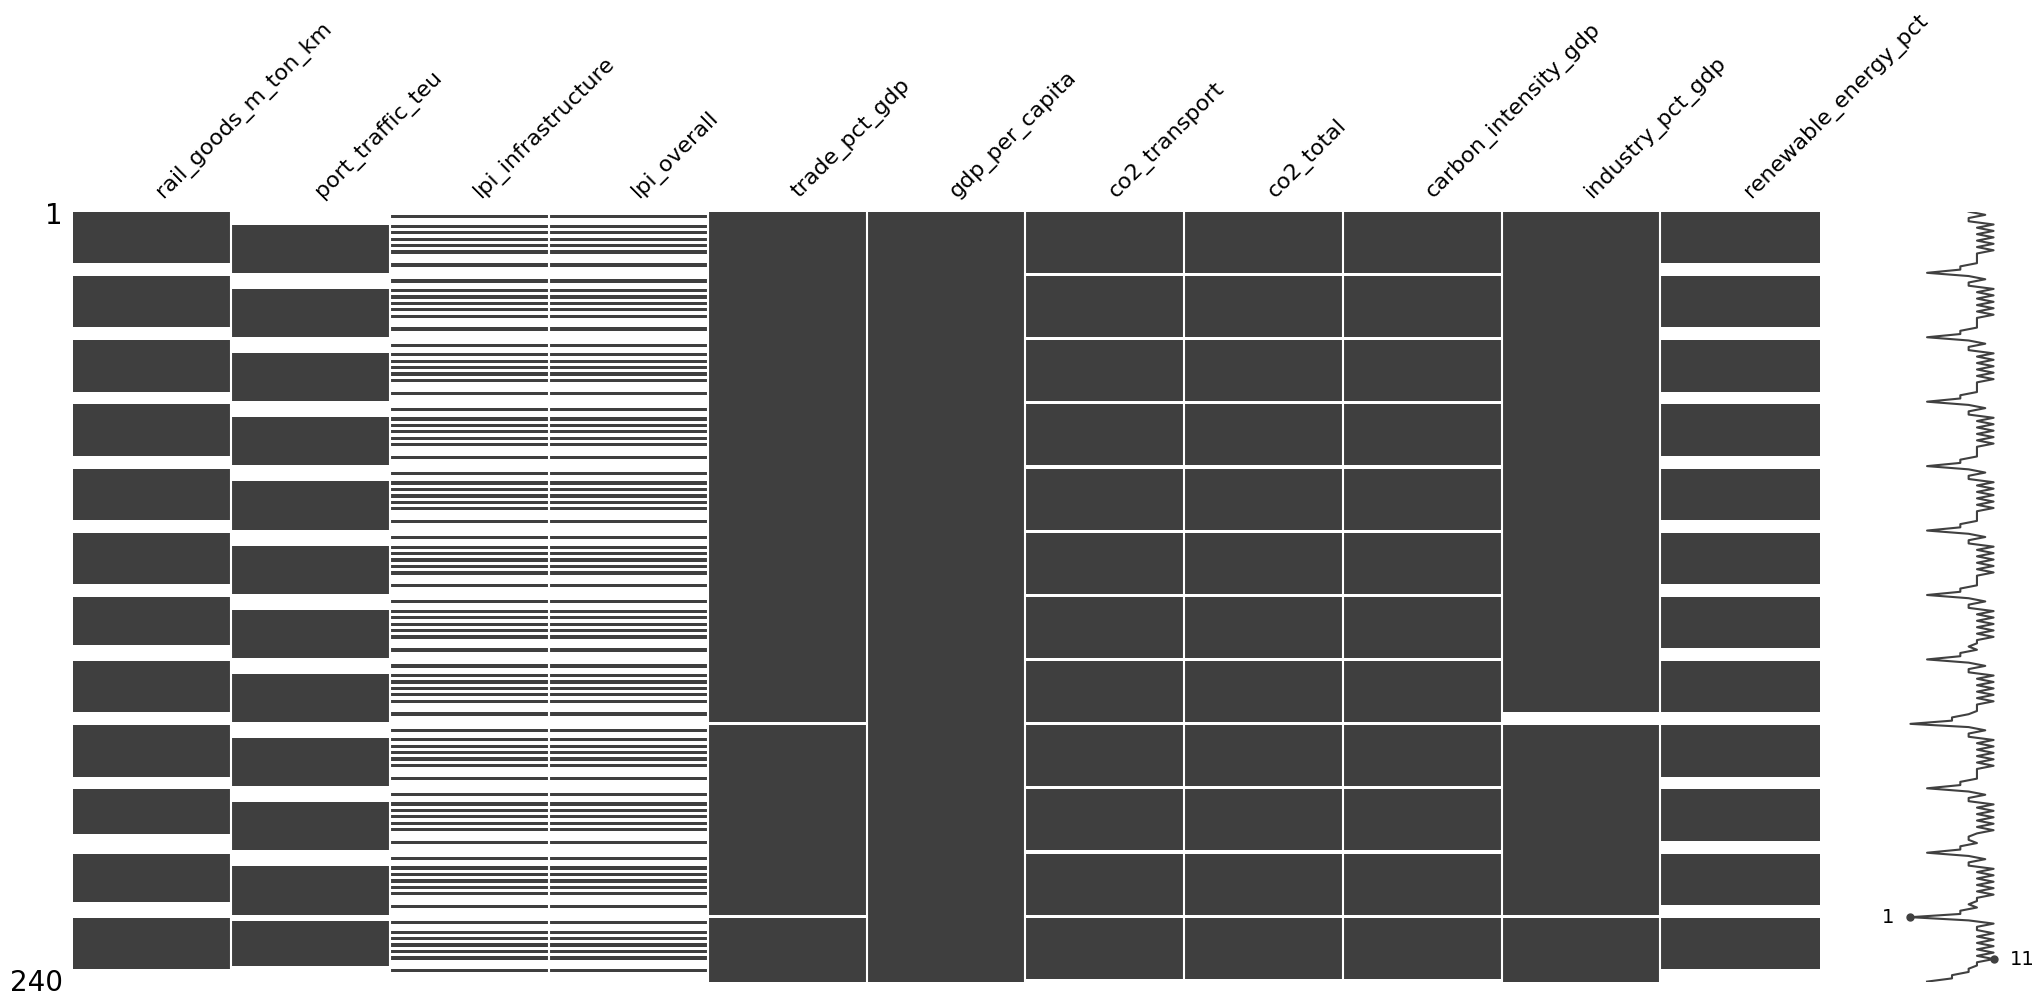

In [17]:
import missingno as msno
msno.matrix(data[data.columns[3:14]])

In [18]:
data = data.sort_values(by=["country", "year"]).reset_index(drop=True)

In [19]:
# 3. İşlem yapılacak hedef sütunları belirle (Ülke, Yıl ve Hariç tutulan dışındakiler)
hedef_sütunlar = [
    col for col in data.columns 
    if col not in ["country", "year","country_code","trade_pct_gdp","industry_pct_gdp"]]

In [20]:
# 4. Ülke grupları içinde doldurma fonksiyonu
def panel_doldur(group):
    # a. İki bilinen değer arasındaki boşlukları lineer doldurur
    group[hedef_sütunlar] = group[hedef_sütunlar].interpolate(method="linear", limit_direction="both")
    
    # b. Sınırlarda (en başta veya en sonda) kalan boşlukları ffill ve bfill ile tamamlar
    group[hedef_sütunlar] = group[hedef_sütunlar].ffill().bfill()
    
    return group

In [21]:
data = data.groupby("country", group_keys=False).apply(panel_doldur)

In [22]:
data.isnull().sum()

country_code            0
year                    0
rail_goods_m_ton_km     0
port_traffic_teu        0
lpi_infrastructure      0
lpi_overall             0
trade_pct_gdp           2
gdp_per_capita          0
co2_transport           0
co2_total               0
carbon_intensity_gdp    0
industry_pct_gdp        5
renewable_energy_pct    0
dtype: int64

In [23]:
# İçinde en az 1 tane boş değer olan satırlar
bos_satirlar = data[data.isnull().any(axis=1)]

# Sadece ülke, yıl ve boşluk olan kısımları incelemek için:
bos_satirlar

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
99,JPN,2025,18340.000,21886683.0,4.2,3.9,NaN,38619.336707,174.9002,972.2670,0.206506,NaN,8.8
236,USA,2022,2239400.714,61191458.0,3.9,3.8,26.907898,64322.233282,1699.4280,4815.7665,0.224162,NaN,10.9
237,USA,2023,2239400.714,54618858.0,3.9,3.8,24.929298,65667.281580,1674.9644,4618.2675,0.208841,NaN,10.9
238,USA,2024,2239400.714,59707490.0,3.9,3.8,25.016017,66856.513170,1678.5621,4632.1649,0.203778,NaN,10.9
239,USA,2025,2239400.714,59707490.0,3.9,3.8,NaN,67945.614650,1678.5621,4632.1649,0.203778,NaN,10.9


In [24]:
# En pratik ve okunabilir yöntem (.isin metodu ile)
data[data["country_code"].isin(["JPN", "USA"])]


,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
80,JPN,2006,23192.000,20016486.0,4.110000,4.020000,29.714873,33880.689009,250.1338,1256.0383,0.289959,29.408231,4.4
81,JPN,2007,23334.000,20016486.0,4.110000,4.020000,32.495720,34426.693712,242.9094,1291.7352,0.293133,29.598688,4.3
82,JPN,2008,22256.000,20016486.0,4.136667,4.003333,33.773803,34008.591515,233.8099,1220.7653,0.280298,29.045923,4.4
83,JPN,2009,20562.000,20016486.0,4.163333,3.986667,24.173039,31993.858805,227.6361,1157.4950,0.282542,27.505033,4.5
84,JPN,2010,20398.000,20016486.0,4.190000,3.970000,28.240015,33311.287238,228.6503,1217.0641,0.285282,28.840615,4.7
85,JPN,2011,19998.000,20631007.0,4.150000,3.950000,29.971385,33306.180226,223.0273,1269.8897,0.298262,27.222025,4.8
86,JPN,2012,20471.000,21167525.0,4.110000,3.930000,30.174300,33909.491186,220.6993,1308.4016,0.302322,27.150182,4.7
87,JPN,2013,21071.000,21442040.0,4.132713,3.922309,33.591369,34636.692475,218.0274,1323.4899,0.299821,27.126636,5.0
88,JPN,2014,21029.000,21662814.0,4.155425,3.914618,36.764325,34996.879676,211.9674,1273.5698,0.285922,28.099984,5.6
89,JPN,2015,21519.000,21094824.0,4.126156,3.942541,34.727631,35664.644611,211.3432,1232.5762,0.271826,29.311161,6.2


In [25]:
# 1. Veriyi ülke ve yıla göre doğru sıralayalım
data = data.sort_values(by=["country_code", "year"]).reset_index(drop=True)

# 2. trade_pct_gdp sütunundaki boşlukları ülke bazında bir önceki yılla (ffill) dolduralım
data["trade_pct_gdp"] = data.groupby("country_code")["trade_pct_gdp"].ffill()

In [26]:
# 1. Önce verinin yıla göre sıralı olduğundan emin olalım (ffill'in doğru çalışması için)
data = data.sort_values(by=["country_code", "year"]).reset_index(drop=True)

# 2. Sadece country_code == 'JPN' olan satırların 'industry_pct_gdp' değerlerini ffill ile dolduralım
data.loc[data["country_code"] == "JPN", "industry_pct_gdp"] = (
    data.loc[data["country_code"] == "JPN", "industry_pct_gdp"].ffill()
)

In [27]:
data[data["country_code"].isin(["JPN", "USA"])]

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
140,JPN,2006,23192.000,20016486.0,4.110000,4.020000,29.714873,33880.689009,250.1338,1256.0383,0.289959,29.408231,4.4
141,JPN,2007,23334.000,20016486.0,4.110000,4.020000,32.495720,34426.693712,242.9094,1291.7352,0.293133,29.598688,4.3
142,JPN,2008,22256.000,20016486.0,4.136667,4.003333,33.773803,34008.591515,233.8099,1220.7653,0.280298,29.045923,4.4
143,JPN,2009,20562.000,20016486.0,4.163333,3.986667,24.173039,31993.858805,227.6361,1157.4950,0.282542,27.505033,4.5
144,JPN,2010,20398.000,20016486.0,4.190000,3.970000,28.240015,33311.287238,228.6503,1217.0641,0.285282,28.840615,4.7
145,JPN,2011,19998.000,20631007.0,4.150000,3.950000,29.971385,33306.180226,223.0273,1269.8897,0.298262,27.222025,4.8
146,JPN,2012,20471.000,21167525.0,4.110000,3.930000,30.174300,33909.491186,220.6993,1308.4016,0.302322,27.150182,4.7
147,JPN,2013,21071.000,21442040.0,4.132713,3.922309,33.591369,34636.692475,218.0274,1323.4899,0.299821,27.126636,5.0
148,JPN,2014,21029.000,21662814.0,4.155425,3.914618,36.764325,34996.879676,211.9674,1273.5698,0.285922,28.099984,5.6
149,JPN,2015,21519.000,21094824.0,4.126156,3.942541,34.727631,35664.644611,211.3432,1232.5762,0.271826,29.311161,6.2


Yukarıdaki doldurmaları yaptık Şimdi ise şuna dikkat etmeliyiz USA zamanla azalan bir industry_pct_gdp izlemekte buna uygun şekilde bir interpolate işlemi yapmamız gerek bu azalmayı bozmak durdurmak istemiyoruz ve aynı oranda azaldığını varsayarak dolduracağız.

In [28]:
# 1. Veriyi sırala
data = data.sort_values(by=["country_code", "year"]).reset_index(drop=True)

sutun = "industry_pct_gdp"
usa_df = data[data["country_code"] == "USA"].copy()

# 2. USA'nin boş olmayan son yıllardaki yüzdesel değişim ortalamasını bulalım (Örn: son 5 değişim)
degisim_oranlari = usa_df[sutun].pct_change()
ort_degisim = degisim_oranlari.dropna().tail(5).mean() # Son 5 yılın ortalama değişim oranı (negatif çıkacaktır)

# 3. Boş olan son 4 yılı bir önceki yılın değerini bu oranla çarparak dolduralım
for idx in usa_df[usa_df[sutun].isnull()].index:
    onceki_deger = data.loc[idx - 1, sutun]
    data.loc[idx, sutun] = onceki_deger * (1 + ort_degisim)

In [29]:
data[data["country_code"].isin(["USA"])].tail(5)

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
235,USA,2021,2239400.714,60874671.0,3.9375,3.8225,25.232726,63096.785615,1663.6783,4754.3785,0.226891,17.575165,10.9
236,USA,2022,2239400.714,61191458.0,3.9000,3.8000,26.907898,64322.233282,1699.4280,4815.7665,0.224162,17.510297,10.9
237,USA,2023,2239400.714,54618858.0,3.9000,3.8000,24.929298,65667.281580,1674.9644,4618.2675,0.208841,17.445668,10.9
238,USA,2024,2239400.714,59707490.0,3.9000,3.8000,25.016017,66856.513170,1678.5621,4632.1649,0.203778,17.381277,10.9
239,USA,2025,2239400.714,59707490.0,3.9000,3.8000,25.016017,67945.614650,1678.5621,4632.1649,0.203778,17.317124,10.9


Tüm veri setinin boşluklarını mantıklı olarak doldurduk. Keşifçi veri analizi kısmına geçebiliriz.

In [30]:
data.columns

Index(['country_code', 'year', 'rail_goods_m_ton_km', 'port_traffic_teu',
       'lpi_infrastructure', 'lpi_overall', 'trade_pct_gdp', 'gdp_per_capita',
       'co2_transport', 'co2_total', 'carbon_intensity_gdp',
       'industry_pct_gdp', 'renewable_energy_pct'],
      dtype='str')

In [31]:
data.isna().sum()

country_code            0
year                    0
rail_goods_m_ton_km     0
port_traffic_teu        0
lpi_infrastructure      0
lpi_overall             0
trade_pct_gdp           0
gdp_per_capita          0
co2_transport           0
co2_total               0
carbon_intensity_gdp    0
industry_pct_gdp        0
renewable_energy_pct    0
dtype: int64

In [32]:
data.to_csv("panel_veri_temiz.csv", index=False, encoding="utf-8-sig")

In [33]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,240.0,2.015500e+03,5.778332e+00,2006.000000,2.010750e+03,2.015500e+03,2.020250e+03,2.025000e+03
rail_goods_m_ton_km,240.0,4.572398e+05,9.633332e+05,5578.000000,1.198200e+04,2.138790e+04,6.849950e+04,3.018200e+06
port_traffic_teu,240.0,2.939506e+07,5.667637e+07,78285.000000,5.705980e+06,1.192702e+07,1.859001e+07,2.997038e+08
lpi_infrastructure,240.0,3.868610e+00,3.780925e-01,2.690000,3.700000e+00,3.950000e+00,4.168749e+00,4.439356e+00
lpi_overall,240.0,3.794694e+00,2.593351e-01,3.040000,3.631875e+00,3.848076e+00,3.990543e+00,4.225967e+00
trade_pct_gdp,240.0,7.076238e+01,3.538651e+01,23.139944,4.865950e+01,6.208407e+01,8.008332e+01,1.841075e+02
gdp_per_capita,240.0,3.702748e+04,2.116098e+04,3883.274644,2.305060e+04,3.629606e+04,4.581754e+04,9.336044e+04
co2_transport,240.0,2.846689e+02,4.677342e+02,14.447900,6.127087e+01,1.095560e+02,1.663439e+02,1.806366e+03
co2_total,240.0,1.665094e+03,3.078902e+03,33.666100,2.847677e+02,3.609365e+02,8.846529e+02,1.312473e+04
carbon_intensity_gdp,240.0,3.138515e-01,2.624132e-01,0.040268,1.623164e-01,2.258533e-01,3.496563e-01,1.359812e+00


Yukarıdaki grafik interaktif değil plotly indirip onunla yapmak daha güzel olur


In [34]:


# İnteraktif çizgi grafiği oluşturma
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y=data.columns[2],  # Railways (Demiryolu Taşımacılığı)
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Demiryolu Taşımacılığı (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        data.columns[2]: "Demiryolu Taşımacılığı (Milyon Ton-Km)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",  # Farenin olduğu yıldaki TÜM ülkelerin değerlerini aynı anda gösterir
    legend_title_text="Ülkeler",
)

# Grafiği tarayıcıda veya Jupyter/VS Code içinde açar
fig.show()

In [35]:
fig.write_html("index.html")

In [36]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,240.0,2.015500e+03,5.778332e+00,2006.000000,2.010750e+03,2.015500e+03,2.020250e+03,2.025000e+03
rail_goods_m_ton_km,240.0,4.572398e+05,9.633332e+05,5578.000000,1.198200e+04,2.138790e+04,6.849950e+04,3.018200e+06
port_traffic_teu,240.0,2.939506e+07,5.667637e+07,78285.000000,5.705980e+06,1.192702e+07,1.859001e+07,2.997038e+08
lpi_infrastructure,240.0,3.868610e+00,3.780925e-01,2.690000,3.700000e+00,3.950000e+00,4.168749e+00,4.439356e+00
lpi_overall,240.0,3.794694e+00,2.593351e-01,3.040000,3.631875e+00,3.848076e+00,3.990543e+00,4.225967e+00
trade_pct_gdp,240.0,7.076238e+01,3.538651e+01,23.139944,4.865950e+01,6.208407e+01,8.008332e+01,1.841075e+02
gdp_per_capita,240.0,3.702748e+04,2.116098e+04,3883.274644,2.305060e+04,3.629606e+04,4.581754e+04,9.336044e+04
co2_transport,240.0,2.846689e+02,4.677342e+02,14.447900,6.127087e+01,1.095560e+02,1.663439e+02,1.806366e+03
co2_total,240.0,1.665094e+03,3.078902e+03,33.666100,2.847677e+02,3.609365e+02,8.846529e+02,1.312473e+04
carbon_intensity_gdp,240.0,3.138515e-01,2.624132e-01,0.040268,1.623164e-01,2.258533e-01,3.496563e-01,1.359812e+00


In [37]:
# İnteraktif çizgi grafiği oluşturma (Konteyner Limanı Trafiği)
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="port_traffic_teu",  # Konteyner Limanı Trafiği
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Konteyner Limanı Trafiği (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        "port_traffic_teu": "Konteyner Limanı Trafiği (TEU)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak farklı bir isimle kaydetme (GitHub için)
fig.write_html("grafik_port_traffic.html")

# Grafiği açar
fig.show()

In [38]:
# 1. Başlangıç ve bitiş yıllarını otomatik tespit etme
country_col = data.columns[0]
year_col = data.columns[1]

first_year = data[year_col].min()
last_year = data[year_col].max()

# 2. Sadece ilk ve son yıla ait liman trafiği verilerini filtreleme
df_filtered = data[data[year_col].isin([first_year, last_year])].copy()

# 3. Veriyi geniş formata getirme (Pivot)
df_pivot = df_filtered.pivot(
    index=country_col, columns=year_col, values="port_traffic_teu"
).reset_index()

# 4. Eksik verisi olan ülkeleri ayıklama
df_pivot = df_pivot.dropna(subset=[first_year, last_year])

# 5. Yüzdesel Artış Oranı (%) Hesaplama
df_pivot["Oransal_Artis_%"] = (
    (df_pivot[last_year] - df_pivot[first_year]) / df_pivot[first_year]
) * 100

# 6. En çok artandan en aza doğru sıralama
df_result = df_pivot.sort_values(by="Oransal_Artis_%", ascending=False)

# 7. Sütun isimlerini ve görünümü düzenleme
df_result = df_result.rename(
    columns={
        country_col: "Ülke",
        first_year: f"{first_year}_TEU",
        last_year: f"{last_year}_TEU",
    }
)

# TEU sayılarını binlik ayraçlı yapma ve yüzdeyi yuvarlama
df_result[f"{first_year}_TEU"] = df_result[f"{first_year}_TEU"].apply(
    lambda x: f"{x:,.0f}"
)
df_result[f"{last_year}_TEU"] = df_result[f"{last_year}_TEU"].apply(
    lambda x: f"{x:,.0f}"
)
df_result["Oransal_Artis_%"] = df_result["Oransal_Artis_%"].round(2)

# Tabloyu çıktı olarak alma
print(df_result.to_string(index=False))

Ülke    2006_TEU    2025_TEU  Oransal_Artis_%
 POL   1,050,345   3,270,784           211.40
 TUR   5,743,429  13,507,070           135.17
 CHN 136,044,183 299,703,800           120.30
 USA  40,266,221  59,707,490            48.28
 ESP  12,500,043  18,114,517            44.92
 FRA   3,915,704   5,371,045            37.17
 NLD  11,334,566  14,517,179            28.08
 ITA   9,762,077  11,927,016            22.18
 GBR   8,224,935   9,621,469            16.98
 JPN  20,016,486  21,886,683             9.34
 CHE     104,366     114,075             9.30
 DEU  13,037,702  13,294,081             1.97


In [39]:

# LPI Altyapı Skoru vs Demiryolu Taşımacılığı Saçılım Grafiği
fig = px.scatter(
    data,
    x="lpi_infrastructure",
    y="lpi_overall",
    color=data.columns[0],  # Ülke bazlı renklendirme
    hover_data=[data.columns[1], "lpi_overall"],  # Yıl ve Genel LPI görünür
    trendline="ols",  # Genel eğilim/trend çizgisini ekler
    title="LPI Altyapı Skoru ve LPI Genel Skor İlişkisi",
    labels={
        "lpi_infrastructure": "LPI Altyapı Skoru (1-5)",
        "lpi_overall": "LPI Genel Skor (1-5)",
        data.columns[0]: "Ülke",
    },
)

fig.update_layout(hovermode="closest")

# GitHub Depon İçin Kaydetme
fig.write_html("grafik_lpi_scatter.html")
fig.show()

In [40]:
fig = px.scatter(
    data,
    x="lpi_infrastructure",
    y="lpi_overall")

fig.show()

In [41]:
corr_val = data["lpi_infrastructure"].corr(data["lpi_overall"])
print(f"LPI Altyapı ve Genel LPI Arasındaki Korelasyon Katsayısı: {corr_val:.4f}")

LPI Altyapı ve Genel LPI Arasındaki Korelasyon Katsayısı: 0.9497


In [42]:
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="co2_transport",  # Taşımacılıktan kaynaklı Karbon Dioxit Emisyonları
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Taşımacılık Kaynaklı Karbon Emisyonları (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        "co2_transport": "Taşımacılıktan Kaynaklı Karbon Dioxit Emisyonları",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak farklı bir isimle kaydetme (GitHub için)
fig.write_html("grafik_co2_transport.html")

# Grafiği açar
fig.show()

In [43]:
# 1. Başlangıç ve bitiş yıllarını tespit etme
country_col = data.columns[0]
year_col = data.columns[1]

first_year = data[year_col].min()
last_year = data[year_col].max()

# 2. İlk ve son yıl verilerini filtreleme
df_filtered = data[data[year_col].isin([first_year, last_year])].copy()

# 3. Veriyi geniş formata getirme (Pivot)
df_pivot = df_filtered.pivot(
    index=country_col, columns=year_col, values="co2_transport"
).reset_index()

# 4. Eksik verisi olan ülkeleri ayıklama
df_pivot = df_pivot.dropna(subset=[first_year, last_year])

# 5. Oransal Değişim (%) Hesaplama
df_pivot["Degisim_%"] = (
    (df_pivot[last_year] - df_pivot[first_year]) / df_pivot[first_year]
) * 100

# 6. En çok artandan en çok azalana doğru sıralama
df_result = df_pivot.sort_values(by="Degisim_%", ascending=False)

# 7. Sütun isimlerini ve görünümü düzenleme
df_result = df_result.rename(
    columns={
        country_col: "Ülke",
        first_year: f"{first_year}_CO2",
        last_year: f"{last_year}_CO2",
    }
)

# Değerleri biçimlendirme ve yuvarlama
df_result[f"{first_year}_CO2"] = df_result[f"{first_year}_CO2"].apply(
    lambda x: f"{x:,.2f}"
)
df_result[f"{last_year}_CO2"] = df_result[f"{last_year}_CO2"].apply(
    lambda x: f"{x:,.2f}"
)
df_result["Degisim_%"] = df_result["Degisim_%"].round(2)

# Tabloyu yazdırma
print(df_result.to_string(index=False))

Ülke 2006_CO2 2025_CO2  Degisim_%
 TUR    41.65    99.29     138.37
 CHN   434.81   928.70     113.59
 POL    38.26    68.61      79.34
 USA 1,806.02 1,678.56      -7.06
 FRA   131.12   119.18      -9.11
 DEU   153.48   138.04     -10.06
 CHE    16.70    14.49     -13.19
 ITA   124.26   104.70     -15.74
 ESP   113.15    95.32     -15.76
 GBR   128.85   106.70     -17.19
 JPN   250.13   174.90     -30.08
 NLD    35.31    24.42     -30.85


In [44]:
data.columns

Index(['country_code', 'year', 'rail_goods_m_ton_km', 'port_traffic_teu',
       'lpi_infrastructure', 'lpi_overall', 'trade_pct_gdp', 'gdp_per_capita',
       'co2_transport', 'co2_total', 'carbon_intensity_gdp',
       'industry_pct_gdp', 'renewable_energy_pct'],
      dtype='str')

In [45]:
# İnteraktif çizgi grafiği oluşturma (Kişi Başı GSYH)
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="gdp_per_capita",  # Kişi Başı GSYH
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Kişi Başı GSYH (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        "gdp_per_capita": "Kişi Başı GSYH (ABD Doları)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak farklı bir isimle kaydetme (GitHub için)
fig.write_html("grafik_gdp_per_capita.html")

# Grafiği açar
fig.show()

In [46]:
# 1. 2006 ve 2025 yıllarını filtreleme
df_filtered = data[data[data.columns[1]].isin([2006, 2025])].copy()

# 2. Veriyi geniş formata getirme (2006 ve 2025 değerlerini yan yana sütun yapma)
df_pivot = df_filtered.pivot(
    index=data.columns[0],
    columns=data.columns[1],
    values="gdp_per_capita",
).reset_index()

# 3. İki yılı da içeren eksiksiz ülke verilerini alma
df_pivot = df_pivot.dropna(subset=[2006, 2025])

# 4. Oransal Değişim (%) Hesaplama
df_pivot["Oransal_Artis_%"] = (
    (df_pivot[2025] - df_pivot[2006]) / df_pivot[2006]
) * 100

# 5. Büyükten küçüğe sıralama
df_result = df_pivot.sort_values(by="Oransal_Artis_%", ascending=False)

# 6. Sütun isimlerini düzenleme ve sonuçları yuvarlama
df_result = df_result.rename(
    columns={
        data.columns[0]: "Ülke",
        2006: "2006_GDP_per_capita",
        2025: "2025_GDP_per_capita",
    }
)

df_result["2006_GDP_per_capita"] = df_result["2006_GDP_per_capita"].round(2)
df_result["2025_GDP_per_capita"] = df_result["2025_GDP_per_capita"].round(2)
df_result["Oransal_Artis_%"] = df_result["Oransal_Artis_%"].round(2)

# Sonuç tablosunu görüntüleme
print(
    df_result[
        ["Ülke", "2006_GDP_per_capita", "2025_GDP_per_capita", "Oransal_Artis_%"]
    ].to_string(index=False)
)

Ülke  2006_GDP_per_capita  2025_GDP_per_capita  Oransal_Artis_%
 CHN              3883.27             13793.21           255.20
 POL              9137.66             18706.74           104.72
 TUR              8078.52             15883.12            96.61
 USA             53596.32             67945.61            26.77
 NLD             43841.09             51817.06            18.19
 DEU             37459.26             44146.64            17.85
 CHE             80448.97             93327.59            16.01
 JPN             33880.69             38619.34            13.99
 FRA             35645.42             39918.89            11.99
 ESP             26899.09             29762.90            10.65
 GBR             43945.00             48422.07            10.19
 ITA             33873.05             34716.14             2.49


In [47]:

# İnteraktif çizgi grafiği oluşturma (Ticaretin GSYH İçindeki Payı)
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="trade_pct_gdp",  # Ticaretin GSYH İçindeki Payı (%)
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Ticaretin GSYH İçindeki Payı (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        "trade_pct_gdp": "Ticaretin GSYH Payı (%)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak farklı bir isimle kaydetme (GitHub için)
fig.write_html("grafik_trade_pct_gdp.html")

# Grafiği açar
fig.show()

In [48]:
# İnteraktif çizgi grafiği oluşturma (Sanayi Katma Değerinin GSYH İçindeki Payı)
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="industry_pct_gdp",  # Sanayinin GSYH İçindeki Payı (%)
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Sanayinin GSYH İçindeki Payı (%)",
    labels={
        data.columns[1]: "Yıl",
        "industry_pct_gdp": "Sanayinin GSYH Payı (%)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak kaydetme (GitHub için)
fig.write_html("grafik_industry_pct_gdp.html")

# Grafiği görüntüleme
fig.show()

In [49]:
data.head()

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
0,CHE,2006,12466.0,104366.0,4.130000,4.020000,105.761917,80448.969678,16.6964,46.6070,0.077411,26.069728,18.1
1,CHE,2007,11952.0,104366.0,4.130000,4.020000,112.709972,82909.135829,17.0355,44.6163,0.071266,26.010666,19.3
2,CHE,2008,12265.0,92464.0,4.143333,4.003333,116.342642,83934.765722,17.4493,45.9807,0.071632,26.134283,19.6
3,CHE,2009,10565.0,78285.0,4.156667,3.986667,109.062731,81288.642958,17.2407,44.6180,0.070880,25.008647,20.0
4,CHE,2010,11074.0,99048.0,4.170000,3.970000,119.202461,83069.427637,17.1762,46.3246,0.071267,24.942703,20.6


In [50]:
data_export = pd.read_excel("C:/Users/demir/Desktop/temizveri/exportss.xlsx")

In [51]:
data_export.shape

(240, 5)

In [52]:
data_export.head()

,Country Name,Country Code,Time,Time Code,High-technology exports (current US$) [TX.VAL.TECH.CD]
0,Turkiye,TUR,2006,YR2006,NaN
1,Turkiye,TUR,2007,YR2007,1.883248e+09
2,Turkiye,TUR,2008,YR2008,1.963946e+09
3,Turkiye,TUR,2009,YR2009,1.587952e+09
4,Turkiye,TUR,2010,YR2010,1.943402e+09


In [53]:
data_export.info()


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 5 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Country Name                                            240 non-null    str    
 1   Country Code                                            240 non-null    str    
 2   Time                                                    240 non-null    int64  
 3   Time Code                                               240 non-null    str    
 4   High-technology exports (current US$) [TX.VAL.TECH.CD]  216 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 9.5 KB


In [54]:
data.head()

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
0,CHE,2006,12466.0,104366.0,4.130000,4.020000,105.761917,80448.969678,16.6964,46.6070,0.077411,26.069728,18.1
1,CHE,2007,11952.0,104366.0,4.130000,4.020000,112.709972,82909.135829,17.0355,44.6163,0.071266,26.010666,19.3
2,CHE,2008,12265.0,92464.0,4.143333,4.003333,116.342642,83934.765722,17.4493,45.9807,0.071632,26.134283,19.6
3,CHE,2009,10565.0,78285.0,4.156667,3.986667,109.062731,81288.642958,17.2407,44.6180,0.070880,25.008647,20.0
4,CHE,2010,11074.0,99048.0,4.170000,3.970000,119.202461,83069.427637,17.1762,46.3246,0.071267,24.942703,20.6


In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_code          240 non-null    str    
 1   year                  240 non-null    int64  
 2   rail_goods_m_ton_km   240 non-null    float64
 3   port_traffic_teu      240 non-null    float64
 4   lpi_infrastructure    240 non-null    float64
 5   lpi_overall           240 non-null    float64
 6   trade_pct_gdp         240 non-null    float64
 7   gdp_per_capita        240 non-null    float64
 8   co2_transport         240 non-null    float64
 9   co2_total             240 non-null    float64
 10  carbon_intensity_gdp  240 non-null    float64
 11  industry_pct_gdp      240 non-null    float64
 12  renewable_energy_pct  240 non-null    float64
dtypes: float64(11), int64(1), str(1)
memory usage: 24.5 KB


In [56]:
data_export.shape

(240, 5)

In [57]:
data_export.head()

,Country Name,Country Code,Time,Time Code,High-technology exports (current US$) [TX.VAL.TECH.CD]
0,Turkiye,TUR,2006,YR2006,NaN
1,Turkiye,TUR,2007,YR2007,1.883248e+09
2,Turkiye,TUR,2008,YR2008,1.963946e+09
3,Turkiye,TUR,2009,YR2009,1.587952e+09
4,Turkiye,TUR,2010,YR2010,1.943402e+09


In [58]:
data.head()

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct
0,CHE,2006,12466.0,104366.0,4.130000,4.020000,105.761917,80448.969678,16.6964,46.6070,0.077411,26.069728,18.1
1,CHE,2007,11952.0,104366.0,4.130000,4.020000,112.709972,82909.135829,17.0355,44.6163,0.071266,26.010666,19.3
2,CHE,2008,12265.0,92464.0,4.143333,4.003333,116.342642,83934.765722,17.4493,45.9807,0.071632,26.134283,19.6
3,CHE,2009,10565.0,78285.0,4.156667,3.986667,109.062731,81288.642958,17.2407,44.6180,0.070880,25.008647,20.0
4,CHE,2010,11074.0,99048.0,4.170000,3.970000,119.202461,83069.427637,17.1762,46.3246,0.071267,24.942703,20.6


In [59]:
# 1. Yıl sütunlarının tip eşleşmesini garantiye alma
data["year"] = data["year"].astype(int)
data_export["Time"] = data_export["Time"].astype(int)

# 2. Değer sütunundaki sayısal olmayan ifadeleri ('..' gibi) NaN yapıp sayısala çevirme
data_export["High-technology exports (current US$) [TX.VAL.TECH.CD]"] = (
    pd.to_numeric(
        data_export[
            "High-technology exports (current US$) [TX.VAL.TECH.CD]"
        ],
        errors="coerce",
    )
)

# 3. Belirttiğin sütunlar üzerinden Left Join ile birleştirme
data = pd.merge(
    data,
    data_export[
        [
            "Country Code",
            "Time",
            "High-technology exports (current US$) [TX.VAL.TECH.CD]",
        ]
    ],
    left_on=["country_code", "year"],
    right_on=["Country Code", "Time"],
    how="left",
)

# 4. Birleşmeden gelen gereksiz eşleşme sütunlarını temizleme
data = data.drop(columns=["Country Code", "Time"], errors="ignore")

# 5. Yeni eklenen sütunun adını daha temiz bir isme dönüştürme
data = data.rename(
    columns={
        "High-technology exports (current US$) [TX.VAL.TECH.CD]": "high_tech_exports_usd"
    }
)

# Kontrol
print("Sütun başarıyla eklendi!")
print(data[["country_code", "year", "high_tech_exports_usd"]].head())

Sütun başarıyla eklendi!
  country_code  year  high_tech_exports_usd
0          CHE  2006                    NaN
1          CHE  2007           3.617785e+10
2          CHE  2008           4.349643e+10
3          CHE  2009           4.039841e+10
4          CHE  2010           4.360999e+10


In [60]:
data.head()

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct,high_tech_exports_usd
0,CHE,2006,12466.0,104366.0,4.130000,4.020000,105.761917,80448.969678,16.6964,46.6070,0.077411,26.069728,18.1,NaN
1,CHE,2007,11952.0,104366.0,4.130000,4.020000,112.709972,82909.135829,17.0355,44.6163,0.071266,26.010666,19.3,3.617785e+10
2,CHE,2008,12265.0,92464.0,4.143333,4.003333,116.342642,83934.765722,17.4493,45.9807,0.071632,26.134283,19.6,4.349643e+10
3,CHE,2009,10565.0,78285.0,4.156667,3.986667,109.062731,81288.642958,17.2407,44.6180,0.070880,25.008647,20.0,4.039841e+10
4,CHE,2010,11074.0,99048.0,4.170000,3.970000,119.202461,83069.427637,17.1762,46.3246,0.071267,24.942703,20.6,4.360999e+10


In [61]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,240.0,2.015500e+03,5.778332e+00,2.006000e+03,2.010750e+03,2.015500e+03,2.020250e+03,2.025000e+03
rail_goods_m_ton_km,240.0,4.572398e+05,9.633332e+05,5.578000e+03,1.198200e+04,2.138790e+04,6.849950e+04,3.018200e+06
port_traffic_teu,240.0,2.939506e+07,5.667637e+07,7.828500e+04,5.705980e+06,1.192702e+07,1.859001e+07,2.997038e+08
lpi_infrastructure,240.0,3.868610e+00,3.780925e-01,2.690000e+00,3.700000e+00,3.950000e+00,4.168749e+00,4.439356e+00
lpi_overall,240.0,3.794694e+00,2.593351e-01,3.040000e+00,3.631875e+00,3.848076e+00,3.990543e+00,4.225967e+00
trade_pct_gdp,240.0,7.076238e+01,3.538651e+01,2.313994e+01,4.865950e+01,6.208407e+01,8.008332e+01,1.841075e+02
gdp_per_capita,240.0,3.702748e+04,2.116098e+04,3.883275e+03,2.305060e+04,3.629606e+04,4.581754e+04,9.336044e+04
co2_transport,240.0,2.846689e+02,4.677342e+02,1.444790e+01,6.127087e+01,1.095560e+02,1.663439e+02,1.806366e+03
co2_total,240.0,1.665094e+03,3.078902e+03,3.366610e+01,2.847677e+02,3.609365e+02,8.846529e+02,1.312473e+04
carbon_intensity_gdp,240.0,3.138515e-01,2.624132e-01,4.026826e-02,1.623164e-01,2.258533e-01,3.496563e-01,1.359812e+00


In [62]:
# İnteraktif çizgi grafiği oluşturma (Yüksek Teknoloji İhracatı)
fig = px.line(
    data,
    x=data.columns[1],  # Time (Yıl)
    y="high_tech_exports_usd",  # Yüksek Teknoloji İhracatı (ABD Doları)
    color=data.columns[0],  # Country Name (Ülke)
    markers=True,  # Çizgilerin üzerine nokta ekler
    title="Ülkelere Göre Yüksek Teknoloji İhracatı (İnteraktif)",
    labels={
        data.columns[1]: "Yıl",
        "high_tech_exports_usd": "Yüksek Teknoloji İhracatı (ABD Doları)",
        data.columns[0]: "Ülke",
    },
)

# Grafiğin düzenini iyileştirme
fig.update_layout(
    hovermode="closest",
    legend_title_text="Ülkeler",
)

# HTML olarak kaydetme (GitHub için)
fig.write_html("grafik_high_tech_exports.html")

# Grafiği açar
fig.show()

In [63]:
data.head()

,country_code,year,rail_goods_m_ton_km,port_traffic_teu,lpi_infrastructure,lpi_overall,trade_pct_gdp,gdp_per_capita,co2_transport,co2_total,carbon_intensity_gdp,industry_pct_gdp,renewable_energy_pct,high_tech_exports_usd
0,CHE,2006,12466.0,104366.0,4.130000,4.020000,105.761917,80448.969678,16.6964,46.6070,0.077411,26.069728,18.1,NaN
1,CHE,2007,11952.0,104366.0,4.130000,4.020000,112.709972,82909.135829,17.0355,44.6163,0.071266,26.010666,19.3,3.617785e+10
2,CHE,2008,12265.0,92464.0,4.143333,4.003333,116.342642,83934.765722,17.4493,45.9807,0.071632,26.134283,19.6,4.349643e+10
3,CHE,2009,10565.0,78285.0,4.156667,3.986667,109.062731,81288.642958,17.2407,44.6180,0.070880,25.008647,20.0,4.039841e+10
4,CHE,2010,11074.0,99048.0,4.170000,3.970000,119.202461,83069.427637,17.1762,46.3246,0.071267,24.942703,20.6,4.360999e+10


In [64]:
# 1. Verinin yıl ve ülke sırasının doğru olduğundan emin olalım
country_col = data.columns[0]
year_col = data.columns[1]
data = data.sort_values(by=[country_col, year_col])

# 2. Ülke bazında gruplayıp ffill ve bfill uygulama
data["high_tech_exports_usd"] = (
    data.groupby(country_col)["high_tech_exports_usd"]
    .ffill()
    .bfill()
)

# Kontrol: Kalan NaN sayısı
missing_count = data["high_tech_exports_usd"].isna().sum()
print(f"İşlem sonrası kalan eksik veri (NaN) sayısı: {missing_count}")


İşlem sonrası kalan eksik veri (NaN) sayısı: 0


In [65]:
# 1. İlk ve son yılı otomatik tespit etme
first_year = data[data.columns[1]].min()
last_year = data[data.columns[1]].max()

# 2. Sadece ilk ve son yıla ait satırları filtreleme
df_filtered = data[data[data.columns[1]].isin([first_year, last_year])].copy()

# 3. Veriyi geniş formata getirme (Pivoting)
df_pivot = df_filtered.pivot(
    index=data.columns[0],
    columns=data.columns[1],
    values="high_tech_exports_usd",
).reset_index()

# 4. İki yılda da verisi olan ülkeleri alma
df_pivot = df_pivot.dropna(subset=[first_year, last_year])

# 5. Oransal Değişim (%) Hesaplama
df_pivot["Oransal_Artis_%"] = (
    (df_pivot[last_year] - df_pivot[first_year]) / df_pivot[first_year]
) * 100

# 6. Büyükten küçüğe sıralama
df_result = df_pivot.sort_values(by="Oransal_Artis_%", ascending=False)

# 7. Sütun isimlerini ve formatı düzenleme
df_result = df_result.rename(
    columns={
        data.columns[0]: "Ülke",
        first_year: f"{first_year}_High_Tech_USD",
        last_year: f"{last_year}_High_Tech_USD",
    }
)

# Okunabilirlik için değerleri yuvarlama
df_result[f"{first_year}_High_Tech_USD"] = df_result[
    f"{first_year}_High_Tech_USD"
].apply(lambda x: f"{x:,.0f}")
df_result[f"{last_year}_High_Tech_USD"] = df_result[
    f"{last_year}_High_Tech_USD"
].apply(lambda x: f"{x:,.0f}")
df_result["Oransal_Artis_%"] = df_result["Oransal_Artis_%"].round(2)

# Tabloyu yazdırma
print(df_result.to_string(index=False))

Ülke 2006_High_Tech_USD 2025_High_Tech_USD  Oransal_Artis_%
 POL      4,362,127,682     40,109,557,279           819.50
 TUR      1,883,247,744      9,903,861,226           425.89
 CHN    343,558,973,511    856,764,726,389           149.38
 CHE     36,177,850,584     89,522,512,070           147.45
 ESP     10,520,143,620     23,796,613,238           126.20
 ITA     27,823,962,961     60,156,857,365           116.21
 DEU    169,568,705,000    246,637,611,895            45.45
 FRA     85,956,078,923    116,591,262,278            35.64
 GBR     68,910,890,387     84,767,727,807            23.01
 NLD     83,812,029,231    103,035,133,130            22.94
 USA    240,663,518,341    232,906,639,404            -3.22
 JPN    128,611,660,344    102,451,366,263           -20.34


POLONYA AB' YE 2004 TE GİRMİŞTİR. bu artış oranında bunun da payı yüksektir

In [66]:
# 1. Analize girecek sayısal değişkenlerimizi tanımlayalım
variables = [
    "trade_pct_gdp",
    "high_tech_exports_usd",
    "port_traffic_teu",
    "co2_transport",
]

# 2. Genel Korelasyon Matrisi (Pearson)
corr_matrix = data[variables].corr()

# Korelasyon matrisini okunabilir formatta yazdıralım
print("--- Genel Korelasyon Matrisi ---")
print(corr_matrix.round(3))

# 3. İnteraktif Isı Haritası (Heatmap) Görselleştirmesi
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Değişkenler Arası Korelasyon Matrisi",
    labels=dict(color="Korelasyon (r)"),
    x=[
        "Ticaret/GSYH",
        "Yüksek Tek. İhracat",
        "Liman Trafiği",
        "Taşımacılık CO2",
    ],
    y=[
        "Ticaret/GSYH",
        "Yüksek Tek. İhracat",
        "Liman Trafiği",
        "Taşımacılık CO2",
    ],
)

fig.update_layout(hovermode="closest")
fig.write_html("grafik_korelasyon_matrisi.html")
fig.show()

--- Genel Korelasyon Matrisi ---
                       trade_pct_gdp  high_tech_exports_usd  port_traffic_teu  \
trade_pct_gdp                  1.000                 -0.289            -0.340   
high_tech_exports_usd         -0.289                  1.000             0.949   
port_traffic_teu              -0.340                  0.949             1.000   
co2_transport                 -0.522                  0.492             0.502   

                       co2_transport  
trade_pct_gdp                 -0.522  
high_tech_exports_usd          0.492  
port_traffic_teu               0.502  
co2_transport                  1.000  


In [67]:
# Ülke bazında değişkenlerin birbiriyle korelasyonunu inceleme
pd.set_option("display.max_columns", None)  # Tüm sütunları göster
pd.set_option("display.max_rows", None)  # Tüm satırları göster
pd.set_option("display.width", 1000)  # Ekran genişliğini artır (yan yana basması için)
pd.set_option("display.colheader_justify", "right")  # Hizalama
country_col = data.columns[0]

country_corrs = data.groupby(country_col)[variables].corr()
print("\n--- Ülke Bazlı Korelasyonlar ---")
print(country_corrs.round(2))


--- Ülke Bazlı Korelasyonlar ---
                                    trade_pct_gdp  high_tech_exports_usd  port_traffic_teu  co2_transport
country_code                                                                                             
CHE          trade_pct_gdp                   1.00                   0.67              0.50          -0.61
             high_tech_exports_usd           0.67                   1.00              0.12          -0.45
             port_traffic_teu                0.50                   0.12              1.00          -0.72
             co2_transport                  -0.61                  -0.45             -0.72           1.00
CHN          trade_pct_gdp                   1.00                  -0.81             -0.79          -0.93
             high_tech_exports_usd          -0.81                   1.00              0.93           0.93
             port_traffic_teu               -0.79                   0.93              1.00           0.90
            

In [68]:
# Pandas'ın çıktı kırpma ve satır bölme özelliklerini kapatalım
pd.set_option("display.max_columns", None)  # Tüm sütunları göster
pd.set_option("display.max_rows", None)  # Tüm satırları göster
pd.set_option("display.width", 1000)  # Ekran genişliğini artır (yan yana basması için)
pd.set_option("display.colheader_justify", "right")  # Hizalama

# Filtreleme ve korelasyon hesaplama
variables = [
    "trade_pct_gdp",
    "high_tech_exports_usd",
    "port_traffic_teu",
    "co2_transport",
]
target_countries = ["CHN", "POL", "TUR"]  # Ülke kodlarına göre

df_sub = data[data["country_code"].isin(target_countries)].copy()
country_corrs = df_sub.groupby("country_code")[variables].corr()

# Çıktıyı tam olarak yazdır
print(country_corrs.round(2))

                                    trade_pct_gdp  high_tech_exports_usd  port_traffic_teu  co2_transport
country_code                                                                                             
CHN          trade_pct_gdp                   1.00                  -0.81             -0.79          -0.93
             high_tech_exports_usd          -0.81                   1.00              0.93           0.93
             port_traffic_teu               -0.79                   0.93              1.00           0.90
             co2_transport                  -0.93                   0.93              0.90           1.00
POL          trade_pct_gdp                   1.00                   0.78              0.88           0.85
             high_tech_exports_usd           0.78                   1.00              0.89           0.89
             port_traffic_teu                0.88                   0.89              1.00           0.92
             co2_transport                   0

In [69]:
# 1. Analize girecek değişkenler
variables = [
    "trade_pct_gdp",
    "high_tech_exports_usd",
    "port_traffic_teu",
    "co2_transport",
]

# Eksenlerde daha şık görünmesi için Türkçe etiketler
labels_tr = [
    "Ticaret/GSYH",
    "Yüksek Tek. İhracat",
    "Liman Trafiği",
    "Taşımacılık CO2",
]

# Ülke kodları ve sunum başlıkları
countries = {
    "CHN": "Çin (China)",
    "POL": "Polonya (Poland)",
    "TUR": "Türkiye (Turkey)",
}

# 2. Her ülke için ayrı korelasyon haritası oluşturma döngüsü
for code, name in countries.items():
    # Ülkeye göre filtreleme (Veri setindeki sütun adın farklıysa 'country_code' kısmını güncelle)
    df_country = data[data["country_code"] == code]

    # Korelasyon matrisi hesaplama
    corr_matrix = df_country[variables].corr()

    # Plotly Isı Haritası (Heatmap)
    fig = px.imshow(
        corr_matrix,
        text_auto=".2f",
        aspect="auto",
        color_continuous_scale="RdBu_r",
        range_color=[-1, 1],  # -1 ile +1 arası sabitleme karşılaştırmayı kolaylaştırır
        title=f"{name} - Değişkenler Arası Korelasyon Matrisi",
        x=labels_tr,
        y=labels_tr,
        labels=dict(color="Korelasyon (r)"),
    )

    fig.update_layout(hovermode="closest", width=650, height=500)

    # HTML olarak kaydetme (GitHub Pages için)
    file_name = f"grafik_korelasyon_{code.lower()}.html"
    fig.write_html(file_name)

    # Gösterim
    fig.show()

    print(f"{name} için görsel '{file_name}' adıyla kaydedildi.")

Çin (China) için görsel 'grafik_korelasyon_chn.html' adıyla kaydedildi.


Polonya (Poland) için görsel 'grafik_korelasyon_pol.html' adıyla kaydedildi.


Türkiye (Turkey) için görsel 'grafik_korelasyon_tur.html' adıyla kaydedildi.


In [70]:
# 2'şerli İlişki Örneği: Liman Trafiği vs Taşımacılık CO2 Emisyonu
fig = px.scatter(
    data,
    x="port_traffic_teu",
    y="co2_transport",
    color=data.columns[0],  # Country Name (Hue = Ülke)
    hover_name=data.columns[0],
    hover_data=["year"],
    trendline="ols",  # Her ülkenin kendi doğrusal trend çizgisini çizer
    title="Liman Trafiği ve CO2 Emisyonu İlişkisi (Ülke Bazlı Trendler)",
    labels={
        "port_traffic_teu": "Konteyner Liman Trafiği (TEU)",
        "co2_transport": "Taşımacılık CO2 Emisyonu",
        data.columns[0]: "Ülke",
    },
)

fig.update_layout(hovermode="closest")
fig.write_html("grafik_scatter_port_co2.html")
fig.show()

In [71]:
# Dataframe içindeki tüm sütunları ve satırları olduğu gibi Excel'e aktarır
excel_file_name = "panel_data_full_raw.xlsx"

data.to_excel(excel_file_name, index=False, sheet_name="FullData")

print(
    f"Tüm değişkenleri içeren veri seti eksiksiz olarak '{excel_file_name}' dosyasına aktarıldı!"
)

Tüm değişkenleri içeren veri seti eksiksiz olarak 'panel_data_full_raw.xlsx' dosyasına aktarıldı!
